### Problem with Linear Regression
Linear Regression assumes:
$
y = w_1x + b
$

But many real-world relationships look like:
- Curved
- Quadratic
- Exponential-like

Example:
- House price vs area (luxury pricing curve)
- Experience vs salary
- Marketing spend vs sales

### Core Idea of Polynomial Regression
In polynomial feature expansion, powers of the original features are added to the model.

Instead of the simple linear model:   
$
y = w_1x + b
$

the model includes higher-order terms of the same feature:
$
y = w_1x + w_2x^2 + w_3x^3 + ... + b
$

Each additional term represents a **polynomial feature** derived from the original variable $x$.


Although the model appears nonlinear in terms of the input feature $x$, it remains a **linear model with respect to the parameters (weights)** $w_1, w_2, w_3, ...$. Each weight multiplies a feature term linearly, and the parameters are not raised to powers or multiplied with each other.

Therefore, the model is **linear in weights but nonlinear in features,** allowing it to capture curved relationships while still using linear regression methods for training.

### Important Insight
Polynomial regression is:
> Linear regression applied to transformed features.

Example:  
Original feature:  
```
x
```

Transformed features:
```
[x, x², x³]
```

Then apply normal linear regression.

### Basic Example Dataset (Curved Relationship)
| Experience (years) | Salary |
| ------------------ | ------ |
| 1                  | 30     |
| 2                  | 35     |
| 3                  | 45     |
| 4                  | 60     |
| 5                  | 80     |

Clearly curved.

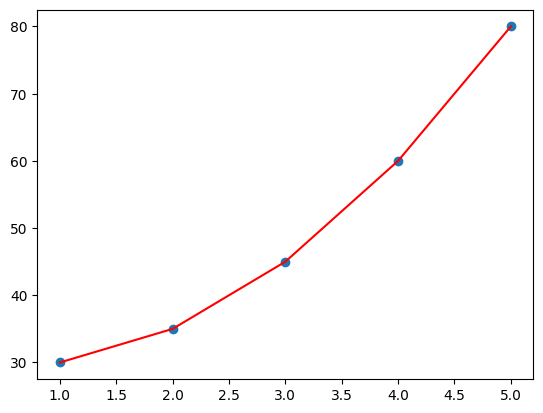

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Data
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([30, 35, 45, 60, 80])

# Transform to polynomial
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Train model
model = LinearRegression()
model.fit(X_poly, y)

# Predictions
y_pred = model.predict(X_poly)

# Plot
plt.scatter(X, y)
plt.plot(X, y_pred, color="red")
plt.show()


### What PolynomialFeature Does
For degree = 2:    
Input:  
```
[ x ]
```
Output:
```
[1, x, x²]
```

For degree = 3:
```
[1, x, x², x³]
```

Bias - Variance Impact
| Degree | Bias     | Variance |
| ------ | -------- | -------- |
| 1      | High     | Low      |
| 2–3    | Balanced | Balanced |
| 10     | Low      | High     |

Higher degree -> more overfitting risk.

### Overfitting Risk
High-degree polynomial:
- Fits noise
- Poor generalization

Example:   
Train R² = 0.99   
Test R² = 0.60

Fix:
- Reduce degree
- Use regularization (Ridge / Lasso)

### Computational Growth Warning
When polynomial features are created for **multiple input variables**, the total number of resulting features increases very quickly. This happens because the model includes **all combinations of features up to a given degree.**

General Formula:  
If there are:  
- $n$ original features
- Polynomial degree $d$

The total number of polynomial features generated is:  
$
\binom{n+d}{d} = \frac{(n+d)!}{d! \, n!}
$

This is a **binomial coefficient**, meaning combinations of $ n + d$ items taken $d$ at a time.

#### Example: 5 Features, Degree = 3
Original features:  
$
x_1, x_2, x_3, x_4, x_5
$

Degree 3 means including:
- Degree 1 terms
- Degree 2 interactions
- Degree 3 interactions

Applying the formula:    
$
\binom{5+3}{3} = \binom{8}{3} = 56
$

So **5 original features become 56 features** after polynomial expansion.

#### What These Features Look Like
##### Degree 1 (original features)
$
x_1, x_2, x_3, x_4, x_5
$

##### Degree 2 terms
$
x_1^2, x_2^2, ...  \\
x_1x_2, x_1x_3, x_1x_4, ...
$

##### Degree 3 terms
$
x_1^3, x_2^3, ... \\
x_1^2x_2, x_1^2x_3, ... \\
x_1x_2x_3, x_1x_2x_4, ...
$

All combinations whose total power is ≤ 3 are included.

#### why This Is Called Feature Explosion
The number grows **combinatorially** as features or degree increase.
| Original Features | Degree | Resulting Features |
| ----------------- | ------ | ------------------ |
| 5                 | 2      | 21                 |
| 5                 | 3      | 56                 |
| 10                | 3      | 286                |
| 20                | 3      | 1771               |
| 20                | 5      | 53130              |



### When to Use Polynomial Regression
- Relationship clearly curved
- Small to medium dataset
- Interpretability still needed

### When NOT to Use
Many features
- Very high dimensional data
- Strong multicollinearity

Better alternatives:
- Tree-based models
- Gradient boosting

### Use Case
#### CPU Temperature vs Load
```
CPU Load -> Temperature
```
Temperature rises faster after certain load.

In [36]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [37]:
data = pd.read_csv('./data/cpu_temperature_vs_load_dataset.csv')
data.head()

,cpu_load_percent,cpu_temperature_celsius
0,37.45,65.76
1,95.07,191.68
2,73.20,134.43
3,59.87,104.95
4,15.60,43.67


In [38]:
X = data[['cpu_load_percent']]
y = data['cpu_temperature_celsius']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Pipeline = preprocessing + model
model = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("lr", LinearRegression())
])

model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [40]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('MSE:', mse)
print('RMSE:', rmse)
print('R2 Score:', r2)

MSE: 3.444018635918769
RMSE: 1.8558067345278089
R2 Score: 0.998623342788537


/Users/jatinrokde/CodeBase/SynapseWorks/MLForge/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


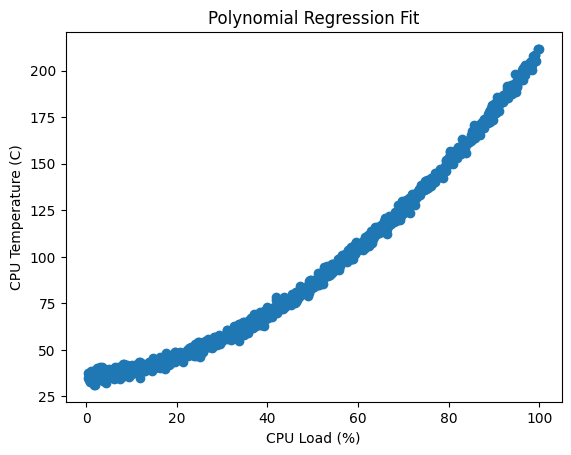

In [41]:
x_range = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
y_curve = model.predict(x_range)

plt.scatter(X, y)
plt.plot(x_range, y_curve)
plt.xlabel('CPU Load (%)')
plt.ylabel('CPU Temperature (C)')
plt.title('Polynomial Regression Fit')
plt.show()

In [42]:
import os

os.makedirs("project-polynomial_regression", exist_ok=True)

model_path = os.path.join("project-polynomial_regression", "cpu_temp_model.pkl")
joblib.dump(model, model_path)
print("Model Saved!")

Model Saved!
